In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from uncertainties import unumpy, ufloat
import pandas as pd
import os

uarray = unumpy.uarray

plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm"})

## Faraday Effect

In [13]:
dir = "FE Data"

fields = {}
angle_diffs_per_length = {}
verdet_constants = {}

for filename in os.listdir(dir):
    glass_type, wavelength, glass_length = filename.split('_')
    wavelength = wavelength.replace('632nm', '632.8nm')
    glass_length = float(glass_length.replace('cm.csv','').replace('-', '.'))

    df = pd.read_csv(os.path.join(dir, filename))
    field = unumpy.uarray(df['magnetic_field'], (2/100) * df['magnetic_field'])
    angle_diff_per_length = (np.pi / 180) * unumpy.uarray(df['angle_diff'], 0.5) / (glass_length / 100)
    
    keyword = f"{glass_type}_{wavelength}"
    
    if not keyword in fields:
        fields[keyword] = field
        angle_diffs_per_length[keyword] = angle_diff_per_length
        continue
        
    np.append(fields[keyword], field)
    np.append(angle_diffs_per_length[keyword], angle_diff_per_length)

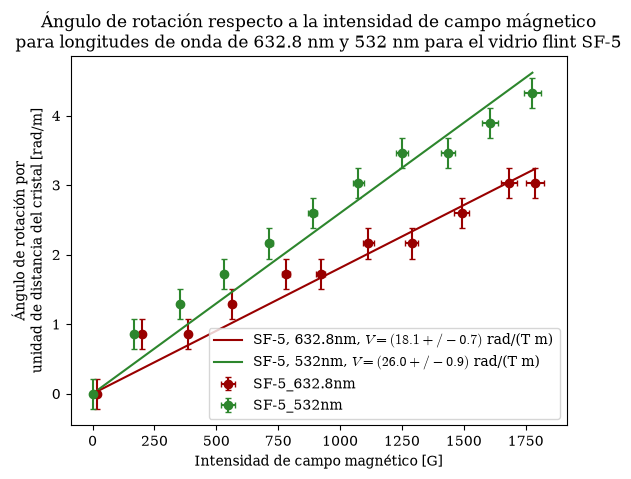

In [31]:
fig, ax = plt.subplots()

colors = ["#990000", "#990000", "#990000", "#2d862d"]

for glass_type_wl, color in zip(fields, colors):
    if "F2" in glass_type_wl:
        continue

    # Scatter plots
    angle_diffs_nominal = [angle.n for angle in angle_diffs_per_length[glass_type_wl]]
    angle_diffs_stdv = [angle.s for angle in angle_diffs_per_length[glass_type_wl]]
    fields_nominal = [field.n for field in fields[glass_type_wl]]
    fields_stdv = [field.s for field in fields[glass_type_wl]]
    ax.errorbar(fields_nominal, angle_diffs_nominal, xerr=fields_stdv, yerr=angle_diffs_stdv,
                label=glass_type_wl, fmt='o', capsize=2, color=color)

    # Curve fits
    fit = lambda x, v: v*x
    popt, pcov = curve_fit(fit, fields_nominal, angle_diffs_nominal) # rad / (Gm)
    verdet_constant = ufloat(popt[0] * 10000, np.sqrt(pcov[0, 0]) * 10000) # rad / (Tm)
    verdet_constants[keyword] = verdet_constant
    min_field, max_field = np.min(fields_nominal), np.max(fields_nominal)
    fields_linspace = np.linspace(min_field, max_field, 10)
    ax.plot(fields_linspace, fit(fields_linspace, *popt), label=f"{glass_type_wl.replace('_', ', ')}, $V=({verdet_constant})$ rad/(T m)", color=color)

    ax.set(xlabel='Intensidad de campo magnético [G]', ylabel='Ángulo de rotación por\nunidad de distancia del cristal [rad/m]',
           title="Ángulo de rotación respecto a la intensidad de campo mágnetico\npara longitudes de onda de 632.8 nm y 532 nm para el " \
                 "vidrio flint SF-5")
    
plt.legend()
plt.savefig("f_effect_SF-5.png", dpi=300)

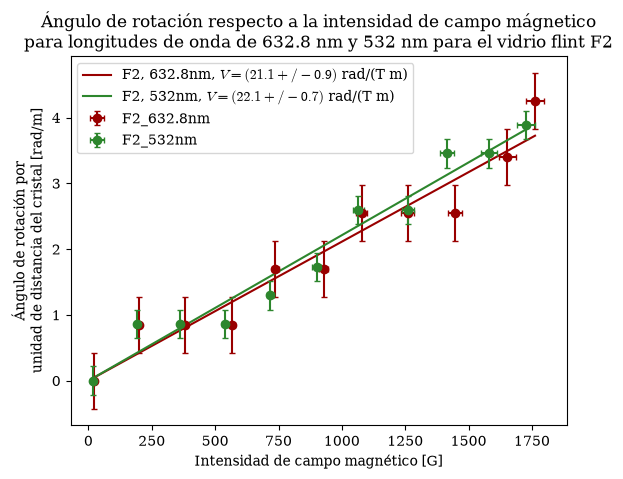

In [37]:
fig, ax = plt.subplots()

colors = ["#990000", "#990000", "#2d862d", "#990000"]

for glass_type_wl, color in zip(fields, colors):
    if "SF" in glass_type_wl:
        continue

    # Scatter plots
    angle_diffs_nominal = [angle.n for angle in angle_diffs_per_length[glass_type_wl]]
    angle_diffs_stdv = [angle.s for angle in angle_diffs_per_length[glass_type_wl]]
    fields_nominal = [field.n for field in fields[glass_type_wl]]
    fields_stdv = [field.s for field in fields[glass_type_wl]]
    ax.errorbar(fields_nominal, angle_diffs_nominal, xerr=fields_stdv, yerr=angle_diffs_stdv,
                label=glass_type_wl, fmt='o', capsize=2, color=color)

    # Curve fits
    fit = lambda x, v: v*x
    popt, pcov = curve_fit(fit, fields_nominal, angle_diffs_nominal) # rad / (Gm)
    verdet_constant = ufloat(popt[0] * 10000, np.sqrt(pcov[0, 0]) * 10000) # rad / (Tm)
    verdet_constants[keyword] = verdet_constant
    min_field, max_field = np.min(fields_nominal), np.max(fields_nominal)
    fields_linspace = np.linspace(min_field, max_field, 10)
    ax.plot(fields_linspace, fit(fields_linspace, *popt), label=f"{glass_type_wl.replace('_', ', ')}, $V=({verdet_constant})$ rad/(T m)", color=color)
    ax.set(xlabel='Intensidad de campo magnético [G]', ylabel='Ángulo de rotación por\nunidad de distancia del cristal [rad/m]',
           title="Ángulo de rotación respecto a la intensidad de campo mágnetico\npara longitudes de onda de 632.8 nm y 532 nm para el " \
                 "vidrio flint F2")

plt.legend()
plt.savefig("f_effect_F2.png", dpi=300)

In [ ]:
from sympy import   
n2−1=1.34533359λ2λ2−0.00997743871+0.209073176λ2λ2−0.0470450767+0.937357162λ2λ2−111.886764

## Optical Activity

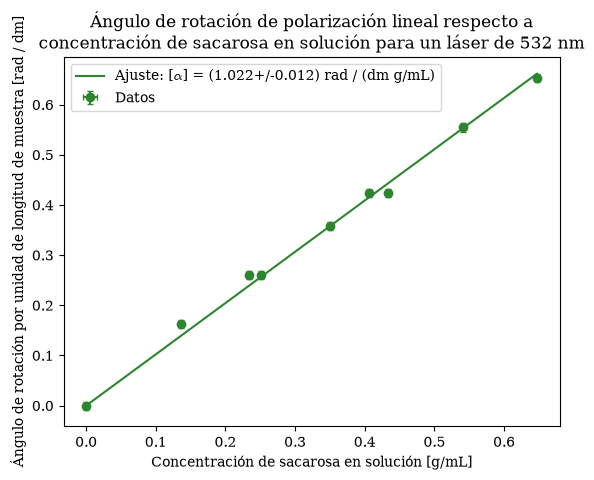

In [36]:
df = pd.read_csv('OA Data/OA_data.csv')
length = 1.07 # dm
water = uarray(df['water'], 0.005) # mL
sugar = df['sugar'] # g
rho_sucrose = 1.587 # g / mL
volume_solution = water + sugar / rho_sucrose
concentration = sugar / volume_solution # g / mL
angles = (np.pi / 180) * uarray(df['angle'], 0.5) / length # rad / dm

fig, ax = plt.subplots()
concentration_nominal = [c.n for c in concentration]
concentration_stdv = [c.s for c in concentration]
angles_nominal = [angle.n for angle in angles]
angles_stdv = [angle.s for angle in angles]

ax.errorbar(concentration_nominal, angles_nominal, xerr=concentration_stdv, yerr=angles_stdv,
            fmt='o', capsize=2, color="#2d862d", label="Datos")

fit = lambda x, a: a*x
popt, pcov = curve_fit(fit, concentration_nominal, angles_nominal)
alpha = ufloat(popt[0], np.sqrt(pcov[0, 0]))
min_concentration, max_concentration = np.min(concentration_nominal), np.max(concentration_nominal)
concentration_linspace = np.linspace(min_concentration, max_concentration, 10)
ax.plot(concentration_linspace, fit(concentration_linspace, *popt), color="#2d862d",
        label=f"Ajuste: [$ \\alpha$] = ({alpha}) rad / (dm g/mL)")

ax.set(xlabel="Concentración de sacarosa en solución [g/mL]", ylabel="Ángulo de rotación por unidad de longitud de muestra [rad / dm]",
       title="Ángulo de rotación de polarización lineal respecto a\nconcentración de sacarosa en solución para un láser de 532 nm")

plt.legend()

plt.savefig("OA.png", dpi=300)